# Run all notebooks in the project

In [2]:
# import necessary libraries

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt

In [34]:
def parse_participant_info(filepath):
    fname = os.path.basename(filepath)
    match = re.match(r"landmarks_([A-Za-z]+)(\d+)_POSE\.csv", fname)
    if not match:
        raise ValueError(f"Nom de fichier inattendu : {fname}")
    return {
        "group":       match.group(1),   # "SZ", "HC", etc.
        "participant": match.group(2),   # "4", "12", etc.
        "participant_id": match.group(1) + match.group(2),  # "SZ4"
    }

In [11]:
# load and read the csv file into a pandas dataframe
df = pd.read_csv("data/SZ/landmarks_SZ1_POSE.csv")

print(df.head())
print(df.shape)
print(df["index"].unique())

   frame  type  index         x         y         z
0      0  pose      0  0.509079  0.153492 -0.239518
1      0  pose      1  0.511716  0.136946 -0.222692
2      0  pose      2  0.514871  0.136040 -0.222996
3      0  pose      3  0.518125  0.135280 -0.222898
4      0  pose      4  0.502163  0.138803 -0.222965
(26934, 6)
[ 0  1  2  3  4  5  6  7  8 11 12 13 14 15 17 19 21 23 24 25 26 27 28 29
 30 31 32 16 18 20 22]


In [33]:
# Vérifier les participants avec wrist data
import os
import pandas as pd

for file in glob.glob("data/*/landmarks_*_POSE.csv"):
    df_temp = pd.read_csv(file)
    has_wrist = (df_temp['index'] == 15).any() and (df_temp['index'] == 16).any()
    participant = os.path.basename(file).split('_')[1]
    print(f"{participant}: {'✓ Has wrist' if has_wrist else '✗ No wrist'}")

P10: ✓ Has wrist
P11: ✓ Has wrist
P12: ✓ Has wrist
P13: ✓ Has wrist
P14: ✓ Has wrist
P15: ✓ Has wrist
P16: ✓ Has wrist
P17: ✓ Has wrist
P18: ✓ Has wrist
P19: ✓ Has wrist
P1: ✓ Has wrist
P20: ✓ Has wrist
P2: ✓ Has wrist
P3: ✓ Has wrist
P4: ✓ Has wrist
P5: ✓ Has wrist
P6: ✓ Has wrist
P7: ✓ Has wrist
P8: ✓ Has wrist
P9: ✓ Has wrist
SZ10: ✓ Has wrist
SZ11: ✓ Has wrist
SZ12: ✓ Has wrist
SZ13: ✓ Has wrist
SZ14: ✓ Has wrist
SZ15: ✓ Has wrist
SZ16: ✓ Has wrist
SZ17: ✓ Has wrist
SZ18: ✓ Has wrist
SZ19: ✓ Has wrist
SZ1: ✓ Has wrist
SZ20: ✓ Has wrist
SZ2: ✓ Has wrist
SZ3: ✓ Has wrist
SZ4: ✗ No wrist
SZ5: ✓ Has wrist
SZ6: ✓ Has wrist
SZ7: ✓ Has wrist
SZ8: ✓ Has wrist
SZ9: ✓ Has wrist


In [12]:
# create a dictionary to map the landmark index to its name
lm = {
0: "nose",

1: "left_eye_inner",
2: "left_eye",
3: "left_eye_outer",

4: "right_eye_inner",
5: "right_eye",
6: "right_eye_outer",

7: "left_ear",
8: "right_ear",

9: "mouth_left",
10: "mouth_right",

11: "left_shoulder",
12: "right_shoulder",

13: "left_elbow",
14: "right_elbow",

15: "left_wrist",
16: "right_wrist",

17: "left_pinky",
18: "right_pinky",

19: "left_index",
20: "right_index",

21: "left_thumb",
22: "right_thumb",

23: "left_hip",
24: "right_hip",

25: "left_knee",
26: "right_knee",

27: "left_ankle",
28: "right_ankle",

29: "left_heel",
30: "right_heel",

31: "left_foot_index",
32: "right_foot_index"
}

In [13]:
# add a new column to the dataframe to store the landmark name
df["lm"] = df["index"].map(lm)

In [14]:
# pivot the dataframe to have one row per frame and columns for each landmark's x, y, z coordinates

df_w = df.pivot(index="frame", columns="lm", values=["x","y","z"])

df_w.columns = [f"{b}_{a}" for a,b in df_w.columns]

df_w = df_w.reset_index()

In [15]:
# calculate additional features based on the existing landmarks

# midpoint between shoulders
df_w["mid_shoulders_x"] = (df_w["left_shoulder_x"] + df_w["right_shoulder_x"]) / 2
df_w["mid_shoulders_y"] = (df_w["left_shoulder_y"] + df_w["right_shoulder_y"]) / 2

# midpoint between hips
df_w["mid_hips_x"] = (df_w["left_hip_x"] + df_w["right_hip_x"]) / 2
df_w["mid_hips_y"] = (df_w["left_hip_y"] + df_w["right_hip_y"]) / 2

# torso center
df_w["torso_center_x"] = (df_w["mid_shoulders_x"] + df_w["mid_hips_x"]) / 2
df_w["torso_center_y"] = (df_w["mid_shoulders_y"] + df_w["mid_hips_y"]) / 2

# center of the image a 0.5 0.5 (cause the coordinates are normalized between 0 and 1) 
df_w["image_center_x"] = 0.5
df_w["image_center_y"] = 0.5


In [16]:
# optional - define the connections between landmarks to verify the pose structure

conns = [
    ("nose", "left_eye_inner"), ("left_eye_inner", "left_eye"), ("left_eye", "left_eye_outer"), ("left_eye_outer", "left_ear"),
    ("nose", "right_eye_inner"), ("right_eye_inner", "right_eye"), ("right_eye", "right_eye_outer"), ("right_eye_outer", "right_ear"),
    ("mouth_left", "mouth_right"),
    ("left_shoulder", "right_shoulder"),
    ("left_shoulder", "left_elbow"), ("left_elbow", "left_wrist"),
    ("right_shoulder", "right_elbow"), ("right_elbow", "right_wrist"),
    ("left_wrist", "left_pinky"), ("left_wrist", "left_index"), ("left_wrist", "left_thumb"),
    ("right_wrist", "right_pinky"), ("right_wrist", "right_index"), ("right_wrist", "right_thumb"),
    ("left_shoulder", "left_hip"), ("right_shoulder", "right_hip"),
    ("left_hip", "right_hip"),
    ("left_hip", "left_knee"), ("left_knee", "left_ankle"), ("left_ankle", "left_heel"), ("left_heel", "left_foot_index"),
    ("right_hip", "right_knee"), ("right_knee", "right_ankle"), ("right_ankle", "right_heel"), ("right_heel", "right_foot_index")
]

pts = [
    "nose", "left_ear", "right_ear",
    "left_shoulder", "right_shoulder", "left_elbow", "right_elbow", "left_wrist", "right_wrist",
    "left_hip", "right_hip", "left_knee", "right_knee", "left_ankle", "right_ankle",
    "left_heel", "right_heel", "left_foot_index", "right_foot_index",
    "mid_shoulders", "mid_hips", "torso_center"
]

def plot_pose(df_w, fr, labels=False, derived=True):
    r = df_w[df_w["frame"] == fr]
    if r.empty:
        print(f"Frame {fr} introuvable")
        return
    r = r.iloc[0]

    p = {}

    # points mediapipe
    for name in lm.values():
        xcol = f"{name}_x"
        ycol = f"{name}_y"
        if xcol in df_w.columns and ycol in df_w.columns:
            if pd.notna(r[xcol]) and pd.notna(r[ycol]):
                p[name] = (r[xcol], r[ycol])

    # points dérivés
    if derived:
        for name in ["mid_shoulders", "mid_hips", "torso_center"]:
            xcol = f"{name}_x"
            ycol = f"{name}_y"
            if xcol in df_w.columns and ycol in df_w.columns:
                if pd.notna(r[xcol]) and pd.notna(r[ycol]):
                    p[name] = (r[xcol], r[ycol])

    plt.figure(figsize=(6, 8))

    # segments
    for a, b in conns:
        if a in p and b in p:
            plt.plot([p[a][0], p[b][0]], [p[a][1], p[b][1]])

    # ligne tronc dérivée
    if derived and "mid_shoulders" in p and "mid_hips" in p:
        plt.plot(
            [p["mid_shoulders"][0], p["mid_hips"][0]],
            [p["mid_shoulders"][1], p["mid_hips"][1]]
        )

    # points
    for name, (x, y) in p.items():
        size = 35 if name in ["mid_shoulders", "mid_hips", "torso_center"] else 18
        plt.scatter(x, y, s=size)
        if labels:
            plt.text(x, y, name, fontsize=8)

    plt.title(f"Frame {fr}")
    plt.xlim(0, 1)
    plt.ylim(1, 0)
    plt.axis("equal")
    plt.show()

C'est ok ! les points m'ont lair detre bien placé donc je vais passer à l'analyse des mouvements



On commence par les mouvements verticaux des mains. 


In [17]:
print(df_w.head())
print(df_w.shape)

   frame  left_ankle_x  left_ear_x  left_elbow_x  left_eye_x  \
0      0      0.538583    0.521224      0.602389    0.514871   
1      1      0.538488    0.520525      0.602321    0.514336   
2      2      0.538439    0.520285      0.602289    0.514219   
3      3      0.538402    0.520024      0.602232    0.513956   
4      4      0.538345    0.519969      0.602200    0.513857   

   left_eye_inner_x  left_eye_outer_x  left_foot_index_x  left_heel_x  \
0          0.511716          0.518125           0.549737     0.533940   
1          0.511216          0.517525           0.553019     0.533958   
2          0.511069          0.517353           0.553227     0.533937   
3          0.510765          0.517052           0.553341     0.533851   
4          0.510616          0.516950           0.553312     0.533812   

   left_hip_x  ...  right_thumb_z  right_wrist_z  mid_shoulders_x  \
0    0.534781  ...            NaN            NaN         0.510652   
1    0.534620  ...            NaN     

In [18]:
# Vertical hand movement relative to shoulders
left_hand_vertical = df_w["left_wrist_y"] - df_w["left_shoulder_y"]
right_hand_vertical = df_w["right_wrist_y"] - df_w["right_shoulder_y"]

# horizontal hand movement relative to shoulders
left_hand_horizontal = df_w["left_wrist_x"] - df_w["left_shoulder_x"]
right_hand_horizontal = df_w["right_wrist_x"] - df_w["right_shoulder_x"]   

# swaying of the body : mid shoulders x movement relative to mid hips x
swaying = df_w["mid_shoulders_x"] - df_w["mid_hips_x"]

# the body moving sideways 
sideways = df_w["torso_center_x"] - df_w["image_center_x"]

# horizontal head movement : nose x movement relative to mid shoulders x
head_horizontal = df_w["nose_x"] - df_w["mid_shoulders_x"]

# vertical head movement : nose y movement relative to mid shoulders y
head_vertical = df_w["nose_y"] - df_w["mid_shoulders_y"]
 
# horizontal foot movement 
left_foot_horizontal = df_w["left_foot_index_x"] - df_w["image_center_x"]
right_foot_horizontal = df_w["right_foot_index_x"] - df_w["image_center_x"]


In [19]:
# interpolate missing values
left_hand_vertical = left_hand_vertical.interpolate().bfill().ffill()
right_hand_vertical = right_hand_vertical.interpolate().bfill().ffill()
left_hand_horizontal = left_hand_horizontal.interpolate().bfill().ffill()
right_hand_horizontal = right_hand_horizontal.interpolate().bfill().ffill()
swaying = swaying.interpolate().bfill().ffill()
sideways = sideways.interpolate().bfill().ffill()
head_horizontal = head_horizontal.interpolate().bfill().ffill()
head_vertical = head_vertical.interpolate().bfill().ffill()
left_foot_horizontal = left_foot_horizontal.interpolate().bfill().ffill()
right_foot_horizontal = right_foot_horizontal.interpolate().bfill().ffill()

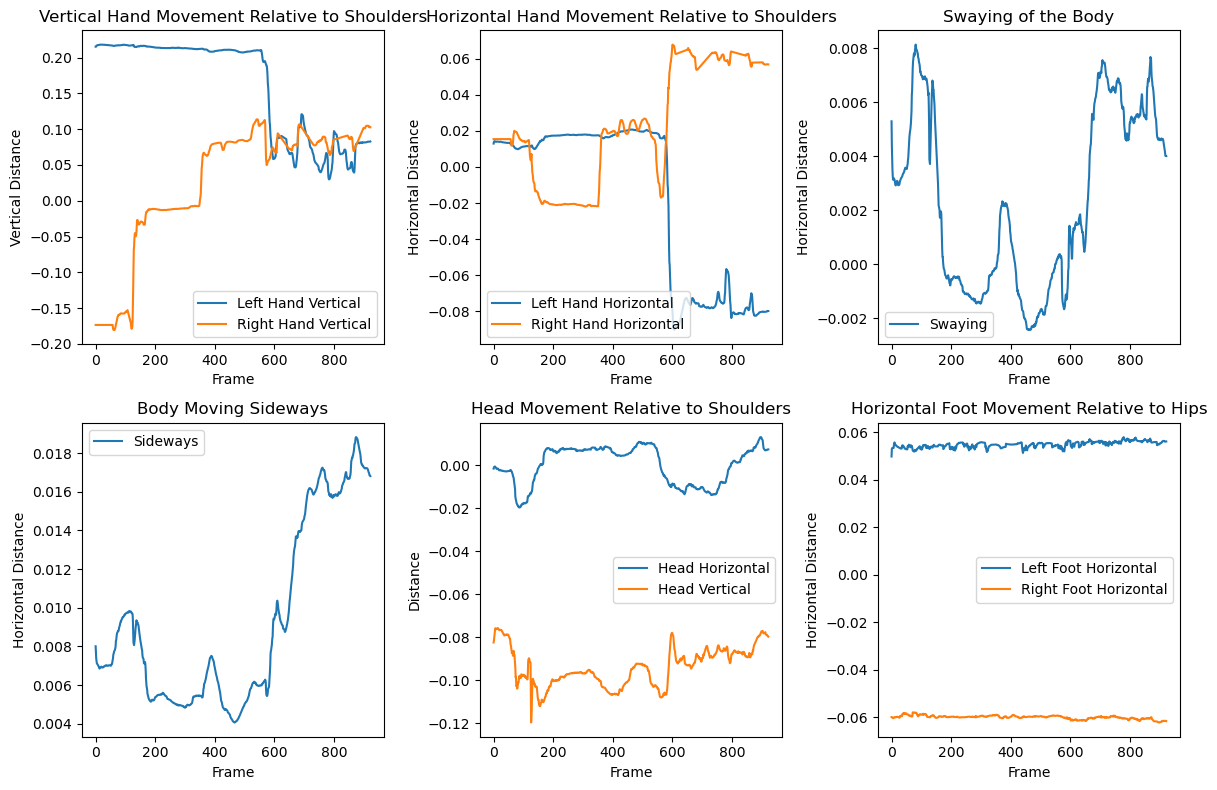

In [20]:
# plot everything 
plt.figure(figsize=(12, 8))
plt.subplot(2, 3, 1)
plt.plot(df_w["frame"], left_hand_vertical, label="Left Hand Vertical")
plt.plot(df_w["frame"], right_hand_vertical, label="Right Hand Vertical")
plt.title("Vertical Hand Movement Relative to Shoulders")
plt.xlabel("Frame")
plt.ylabel("Vertical Distance")
plt.legend()

plt.subplot(2, 3, 2)
plt.plot(df_w["frame"], left_hand_horizontal, label="Left Hand Horizontal")
plt.plot(df_w["frame"], right_hand_horizontal, label="Right Hand Horizontal")
plt.title("Horizontal Hand Movement Relative to Shoulders")
plt.xlabel("Frame")
plt.ylabel("Horizontal Distance")
plt.legend()

plt.subplot(2, 3, 3)
plt.plot(df_w["frame"], swaying, label="Swaying")
plt.title("Swaying of the Body")
plt.xlabel("Frame")
plt.ylabel("Horizontal Distance")
plt.legend()

plt.subplot(2, 3, 4)
plt.plot(df_w["frame"], sideways, label="Sideways")
plt.title("Body Moving Sideways")
plt.xlabel("Frame")
plt.ylabel("Horizontal Distance")
plt.legend()

plt.subplot(2, 3, 5)
plt.plot(df_w["frame"], head_horizontal, label="Head Horizontal")
plt.plot(df_w["frame"], head_vertical, label="Head Vertical")
plt.title("Head Movement Relative to Shoulders")
plt.xlabel("Frame")
plt.ylabel("Distance")
plt.legend()

plt.subplot(2, 3, 6)
plt.plot(df_w["frame"], left_foot_horizontal, label="Left Foot Horizontal")
plt.plot(df_w["frame"], right_foot_horizontal, label="Right Foot Horizontal")
plt.title("Horizontal Foot Movement Relative to Hips")
plt.xlabel("Frame")
plt.ylabel("Horizontal Distance")
plt.legend()

plt.tight_layout()
plt.show()

In [21]:
def lowpass_filter(data, cutoff, fs, order):
    """
    Apply a Butterworth low-pass filter to a 1D signal.

    Parameters
    ----------
    data : array-like
        Input signal.
    cutoff : float
        Cutoff frequency in Hz.
    fs : float
        Sampling frequency in Hz.
    order : int
        Filter order.

    Returns
    -------
    np.ndarray
        Filtered signal.
    """
    data = np.asarray(data, dtype=float)

    nyquist = 0.5 * fs
    normalized_cutoff = cutoff / nyquist

    if not 0 < normalized_cutoff < 1:
        raise ValueError("cutoff must be strictly between 0 and fs/2.")

    b, a = butter(N=order, Wn=normalized_cutoff, btype="low", analog=False)
    filtered = filtfilt(b, a, data)

    return filtered

In [22]:
cutoff= 5
fs = 30
order = 4

# apply low-pass filter to the features

left_hand_vertical_f = lowpass_filter(left_hand_vertical, cutoff, fs, order)
right_hand_vertical_f = lowpass_filter(right_hand_vertical, cutoff, fs, order)

left_hand_horizontal_f = lowpass_filter(left_hand_horizontal, cutoff, fs, order)
right_hand_horizontal_f = lowpass_filter(right_hand_horizontal, cutoff, fs, order)

swaying_f = lowpass_filter(swaying, cutoff, fs, order)

sideways_f = lowpass_filter(sideways, cutoff, fs, order)

head_horizontal_f = lowpass_filter(head_horizontal, cutoff, fs, order)

head_vertical_f = lowpass_filter(head_vertical, cutoff, fs, order)

left_foot_horizontal_f = lowpass_filter(left_foot_horizontal, cutoff, fs, order)
right_foot_horizontal_f = lowpass_filter(right_foot_horizontal, cutoff, fs, order)

In [23]:
# center the filtered features by subtracting the mean
left_hand_vertical_f = left_hand_vertical_f - np.mean(left_hand_vertical_f)
right_hand_vertical_f = right_hand_vertical_f - np.mean(right_hand_vertical_f)

left_hand_horizontal_f = left_hand_horizontal_f - np.mean(left_hand_horizontal_f)
right_hand_horizontal_f = right_hand_horizontal_f - np.mean(right_hand_horizontal_f)

swaying_f = swaying_f - np.mean(swaying_f)
sideways_f = sideways_f - np.mean(sideways_f)

head_horizontal_f = head_horizontal_f - np.mean(head_horizontal_f)
head_vertical_f = head_vertical_f - np.mean(head_vertical_f)

left_foot_horizontal_f = left_foot_horizontal_f - np.mean(left_foot_horizontal_f)
right_foot_horizontal_f = right_foot_horizontal_f - np.mean(right_foot_horizontal_f)

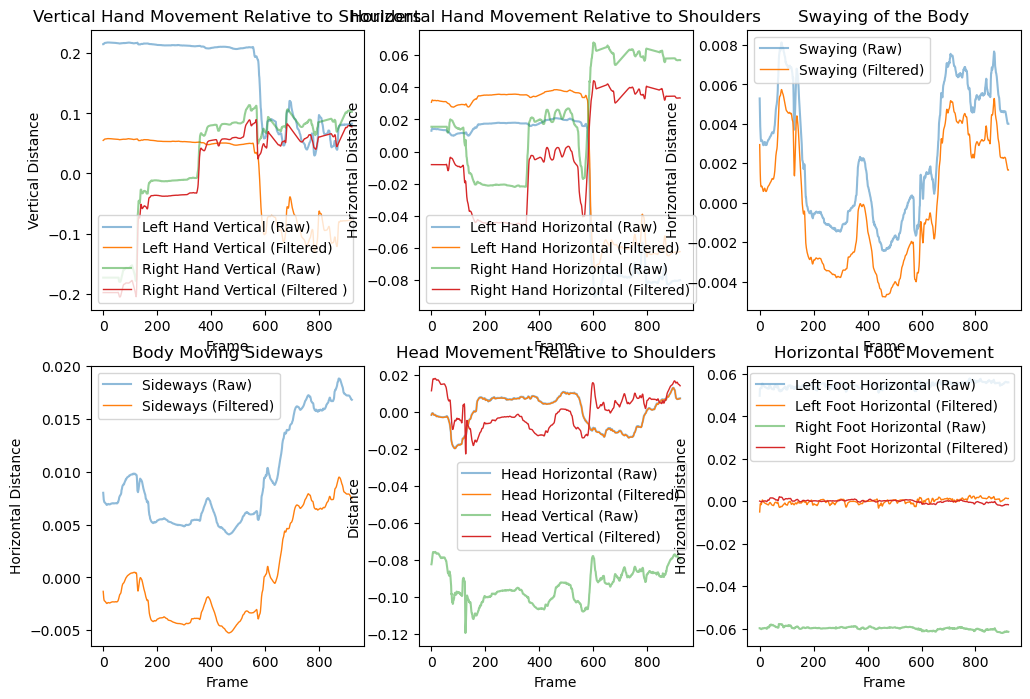

In [24]:
# plot everything again comparing raw and filtered signals
plt.figure(figsize=(12, 8))
plt.subplot(2, 3, 1)
plt.plot(df_w["frame"], left_hand_vertical, label="Left Hand Vertical (Raw)", alpha=0.5)
plt.plot(df_w["frame"], left_hand_vertical_f, label="Left Hand Vertical (Filtered)", linewidth=1)
plt.plot(df_w["frame"], right_hand_vertical, label="Right Hand Vertical (Raw)", alpha=0.5)
plt.plot(df_w["frame"], right_hand_vertical_f, label="Right Hand Vertical (Filtered )", linewidth=1)
plt.title("Vertical Hand Movement Relative to Shoulders")  
plt.xlabel("Frame")
plt.ylabel("Vertical Distance")
plt.legend()

plt.subplot(2, 3, 2)
plt.plot(df_w["frame"], left_hand_horizontal, label="Left Hand Horizontal (Raw)", alpha=0.5)
plt.plot(df_w["frame"], left_hand_horizontal_f, label="Left Hand Horizontal (Filtered)", linewidth=1)
plt.plot(df_w["frame"], right_hand_horizontal, label="Right Hand Horizontal (Raw)", alpha=0.5)
plt.plot(df_w["frame"], right_hand_horizontal_f, label="Right Hand Horizontal (Filtered)", linewidth=1)
plt.title("Horizontal Hand Movement Relative to Shoulders") 
plt.xlabel("Frame")
plt.ylabel("Horizontal Distance")
plt.legend()

plt.subplot(2, 3, 3)
plt.plot(df_w["frame"], swaying, label="Swaying (Raw)", alpha=0.5)
plt.plot(df_w["frame"], swaying_f, label="Swaying (Filtered)", linewidth=1)
plt.title("Swaying of the Body")
plt.xlabel("Frame")
plt.ylabel("Horizontal Distance")
plt.legend()

plt.subplot(2, 3, 4)
plt.plot(df_w["frame"], sideways, label="Sideways (Raw)", alpha=0.5)
plt.plot(df_w["frame"], sideways_f, label="Sideways (Filtered)", linewidth=1)
plt.title("Body Moving Sideways")   
plt.xlabel("Frame")
plt.ylabel("Horizontal Distance")
plt.legend()

plt.subplot(2, 3, 5)
plt.plot(df_w["frame"], head_horizontal, label="Head Horizontal (Raw)", alpha=0.5)
plt.plot(df_w["frame"], head_horizontal_f, label="Head Horizontal (Filtered)", linewidth=1)
plt.plot(df_w["frame"], head_vertical, label="Head Vertical (Raw)", alpha=0.5)
plt.plot(df_w["frame"], head_vertical_f, label="Head Vertical (Filtered)", linewidth=1)
plt.title("Head Movement Relative to Shoulders")
plt.xlabel("Frame")
plt.ylabel("Distance")
plt.legend()

plt.subplot(2, 3, 6)
plt.plot(df_w["frame"], left_foot_horizontal, label="Left Foot Horizontal (Raw)", alpha=0.5)
plt.plot(df_w["frame"], left_foot_horizontal_f, label="Left Foot Horizontal (Filtered)", linewidth=1)
plt.plot(df_w["frame"], right_foot_horizontal, label="Right Foot Horizontal (Raw)", alpha=0.5)
plt.plot(df_w["frame"], right_foot_horizontal_f, label="Right Foot Horizontal (Filtered)", linewidth=1)
plt.title("Horizontal Foot Movement")
plt.xlabel("Frame")
plt.ylabel("Horizontal Distance")
plt.legend()

In [25]:
def get_local_extrema_derivative(signal):
    signal = np.asarray(signal, dtype=float)
    d = np.diff(signal)

    max_idx = []
    min_idx = []

    for i in range(1, len(d)):
        if d[i - 1] > 0 and d[i] <= 0:
            max_idx.append(i)
        elif d[i - 1] < 0 and d[i] >= 0:
            min_idx.append(i)

    return np.array(min_idx), np.array(max_idx)

In [26]:
left_hand_min_idx, left_hand_max_idx = get_local_extrema_derivative(left_hand_vertical_f)
right_hand_min_idx, right_hand_max_idx = get_local_extrema_derivative(right_hand_vertical_f)
left_hand_horizontal_min_idx, left_hand_horizontal_max_idx = get_local_extrema_derivative(left_hand_horizontal_f)
right_hand_horizontal_min_idx, right_hand_horizontal_max_idx = get_local_extrema_derivative(right_hand_horizontal_f)


swaying_min_idx, swaying_max_idx = get_local_extrema_derivative(swaying_f)
sideways_min_idx, sideways_max_idx = get_local_extrema_derivative(sideways_f)

head_horizontal_min_idx, head_horizontal_max_idx = get_local_extrema_derivative(head_horizontal_f)
head_vertical_min_idx, head_vertical_max_idx = get_local_extrema_derivative(head_vertical_f)

left_foot_horizontal_min_idx, left_foot_horizontal_max_idx = get_local_extrema_derivative(left_foot_horizontal_f)
right_foot_horizontal_min_idx, right_foot_horizontal_max_idx = get_local_extrema_derivative(right_foot_horizontal_f)

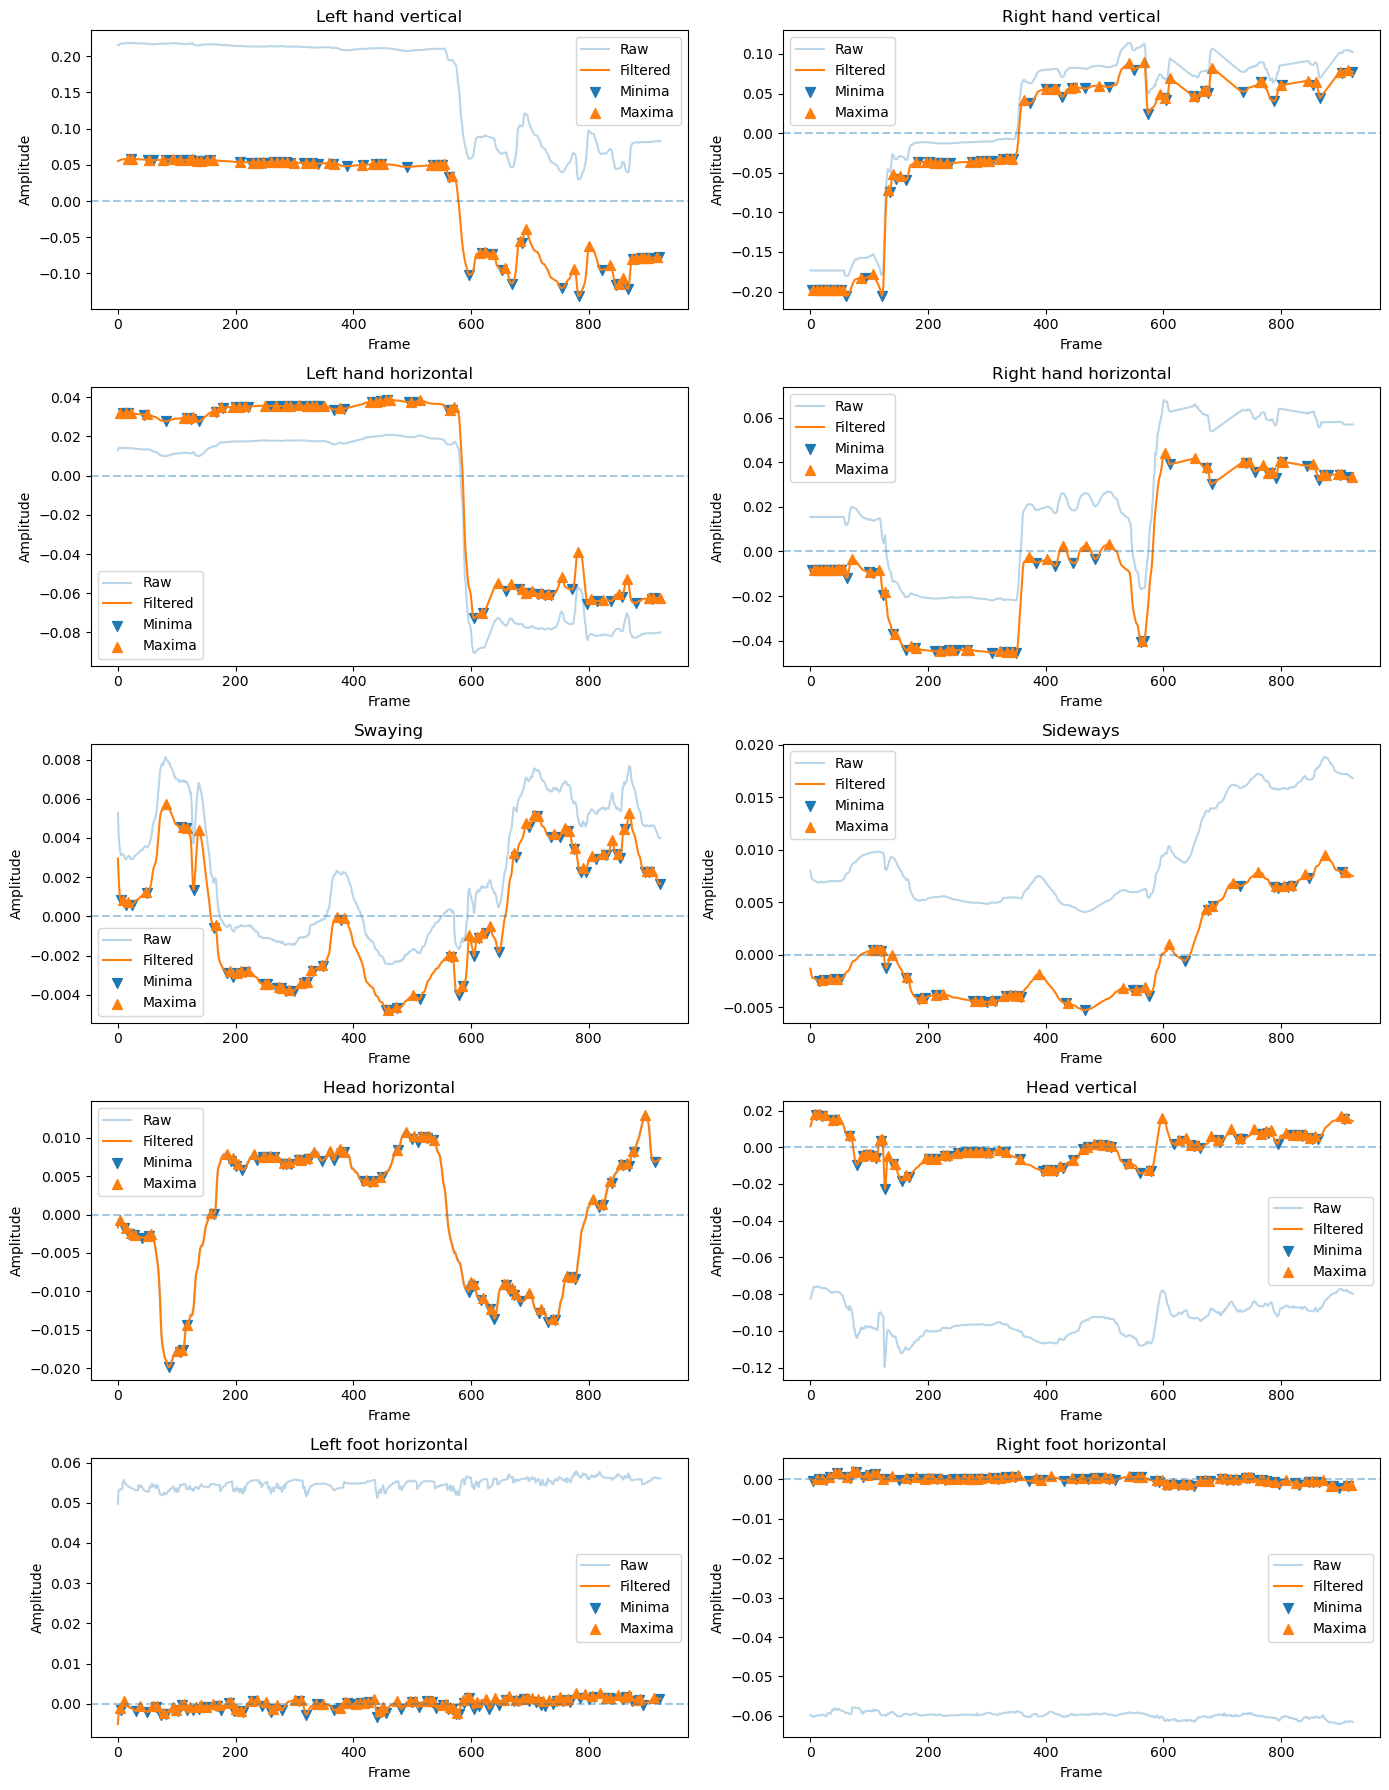

In [27]:
fig, axes = plt.subplots(5, 2, figsize=(14, 18))
axes = axes.ravel()

signals = [
    ("Left hand vertical", left_hand_vertical, left_hand_vertical_f, left_hand_min_idx, left_hand_max_idx),
    ("Right hand vertical", right_hand_vertical, right_hand_vertical_f, right_hand_min_idx, right_hand_max_idx),
    ("Left hand horizontal", left_hand_horizontal, left_hand_horizontal_f, left_hand_horizontal_min_idx, left_hand_horizontal_max_idx),
    ("Right hand horizontal", right_hand_horizontal, right_hand_horizontal_f, right_hand_horizontal_min_idx, right_hand_horizontal_max_idx),
    ("Swaying", swaying, swaying_f, swaying_min_idx, swaying_max_idx),
    ("Sideways", sideways, sideways_f, sideways_min_idx, sideways_max_idx),
    ("Head horizontal", head_horizontal, head_horizontal_f, head_horizontal_min_idx, head_horizontal_max_idx),
    ("Head vertical", head_vertical, head_vertical_f, head_vertical_min_idx, head_vertical_max_idx),
    ("Left foot horizontal", left_foot_horizontal, left_foot_horizontal_f, left_foot_horizontal_min_idx, left_foot_horizontal_max_idx),
    ("Right foot horizontal", right_foot_horizontal, right_foot_horizontal_f, right_foot_horizontal_min_idx, right_foot_horizontal_max_idx),
]

frames = df_w["frame"].to_numpy()

for ax, (title, raw_signal, filtered_signal, min_idx, max_idx) in zip(axes, signals):
    raw_signal = np.asarray(raw_signal, dtype=float)
    filtered_signal = np.asarray(filtered_signal, dtype=float)

    ax.plot(frames, raw_signal, alpha=0.3, label="Raw")
    ax.plot(frames, filtered_signal, linewidth=1.5, label="Filtered")
    ax.scatter(frames[min_idx], filtered_signal[min_idx], marker="v", s=50, label="Minima")
    ax.scatter(frames[max_idx], filtered_signal[max_idx], marker="^", s=50, label="Maxima")

    ax.axhline(0, linestyle="--", alpha=0.4)
    ax.set_title(title)
    ax.set_xlabel("Frame")
    ax.set_ylabel("Amplitude")
    ax.legend()

plt.tight_layout()
plt.show()

In [28]:
def motion_sum_1d(signal) -> float:
    signal = pd.to_numeric(pd.Series(signal), errors="coerce")
    return float(signal.diff().abs().fillna(0).sum())

In [29]:
def motion_sum_2d(x_signal, y_signal) -> float:
    x = pd.to_numeric(pd.Series(x_signal), errors="coerce")
    y = pd.to_numeric(pd.Series(y_signal), errors="coerce")

    dx = x.diff()
    dy = y.diff()

    step = np.sqrt(dx**2 + dy**2)
    return float(step.fillna(0).sum())

In [30]:
left_hand_motion_2d = motion_sum_2d(left_hand_horizontal_f, left_hand_vertical_f)
right_hand_motion_2d = motion_sum_2d(right_hand_horizontal_f, right_hand_vertical_f)

print("Left hand total 2D motion:", left_hand_motion_2d)
print("Right hand total 2D motion:", right_hand_motion_2d)

Left hand total 2D motion: 0.8261341952923005
Right hand total 2D motion: 0.9590799368465832


In [31]:
# CODE DE MATYS pour calculer le movement quantity index (Précloux et al 2026)

def motion_sum_for_marker(df: pd.DataFrame, name: str) -> float:
    """Somme des déplacements euclidiens frame->frame pour un marqueur (x,y,z), insensible à la casse."""
    lc = {c.lower(): c for c in df.columns}
    try:
        cx, cy, cz = lc[f"{name.lower()}_x"], lc[f"{name.lower()}_y"], lc[f"{name.lower()}_z"]
    except KeyError:
        return np.nan  # colonnes manquantes
    # cast numeric (au cas où Excel a des strings)
    x = pd.to_numeric(df[cx], errors="coerce")
    y = pd.to_numeric(df[cy], errors="coerce")
    z = pd.to_numeric(df[cz], errors="coerce")
    step = np.sqrt(x.diff()**2 + y.diff()**2 + z.diff()**2)
    return float(step.fillna(0).sum())

In [32]:
def compute_extrema_metrics(signal, frames):
    """
    À partir d'un signal filtré et centré, calcule :
    - expansiveness     : somme des amplitudes entre extrema successifs
    - quantity_of_motion: nombre total d'extrema (nb_min + nb_max)
    - amplitudes        : liste des Amp_i individuelles
    - delta_t           : liste des ΔT_i (en frames) entre extrema successifs
    """
    signal = np.asarray(signal, dtype=float)
    frames = np.asarray(frames)

    min_idx, max_idx = get_local_extrema_derivative(signal)

    # Fusionner et trier tous les extrema par position temporelle
    all_idx = np.sort(np.concatenate([min_idx, max_idx]))

    amplitudes = []
    delta_t    = []

    for i in range(1, len(all_idx)):
        i0, i1 = all_idx[i - 1], all_idx[i]
        amp = abs(signal[i1] - signal[i0])
        dt  = int(frames[i1] - frames[i0])
        amplitudes.append(amp)
        delta_t.append(dt)

    expansiveness      = float(np.sum(amplitudes))
    quantity_of_motion = len(min_idx) + len(max_idx)

    return {
        "expansiveness":      expansiveness,
        "quantity_of_motion": quantity_of_motion,
        "amplitudes":         amplitudes,   # liste des Amp_i
        "delta_t":            delta_t,      # liste des ΔT_i (frames)
        "n_minima":           len(min_idx),
        "n_maxima":           len(max_idx),
    }